# Notebook 13 — Merge October + December: Dedup Audit & Drift Analysis

**Roadmap:** Priority 1 (`docs/next_steps_roadmap.md`). December is currently the only true held-out
test set; merging it into training **destroys it**. This notebook does the merge carefully and documents
everything so the decision is reversible and auditable.

**Plan**
1. Load both extractions (raw, provenance kept)
2. Within-extraction `url` dedup (December has internal duplicate urls)
3. Cross-extraction `url` dedup — keep the most recent extraction (December)
4. Bonus: asking-price drift on listings present in **both** extractions
5. Near-duplicate audit — identical `(brand, model, year, km, price)` under different urls (leakage risk)
6. Market drift — Oct vs Dec price distribution per segment (brand × age bucket)
7. Clean the merged set and save it version-tagged (NB14 input)
8. Log the merge summary to MLflow

> **Data source note:** this notebook reads from the local copy under `data/external/` (not the
> TCC-protected `~/Documents` path used by earlier notebooks), so it runs in any environment with
> repo access.

> **Caveat carried throughout:** LeBonCoin prices are **asking prices**, not transaction prices.
> Any "price change" is negotiation/relisting drift, not realized sale-price movement. Document this
> for clients.

## 1. Setup & Constants

In [1]:
import os
import sys
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import data_processing
from data_processing import CarDataProcessor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

# ── Constants ────────────────────────────────────────────────────────────────
CURRENT_YEAR = 2025
VERSION_TAG  = 'v1'
SEED         = 42
MLFLOW_URI   = f"file://{project_root / 'mlruns'}"

# Cleaning config — identical to the validated V2 pipeline (NB12)
CLEAN_PARAMS = dict(
    price_floor=500,
    price_ceiling=250000,
    iqr_large_group_threshold=50,
    iqr_min_group_size=10,
    verbose=True,
)

# ── Paths (local copy, not the protected ~/Documents path) ───────────────────
EXTERNAL    = project_root / 'data' / 'external'
oct_dir     = EXTERNAL / 'le_boncoin_13_oct_2025'
dec_dir     = EXTERNAL / 'le_boncoin_16_dec_2025'
processed   = project_root / 'data' / 'processed'
output_dir  = project_root / 'output'
processed.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

EXTRACTIONS = {'oct_2025': oct_dir, 'dec_2025': dec_dir}
EXTRACTION_RANK = {'oct_2025': 0, 'dec_2025': 1}   # higher = more recent = kept on conflict

print('October dir :', oct_dir, '| exists:', oct_dir.exists())
print('December dir:', dec_dir, '| exists:', dec_dir.exists())
print('MLflow store:', MLFLOW_URI)
print('Version tag :', VERSION_TAG)
print('OK setup')

October dir : /Users/brunobrumbrum/car_price_prediction/data/external/le_boncoin_13_oct_2025 | exists: True
December dir: /Users/brunobrumbrum/car_price_prediction/data/external/le_boncoin_16_dec_2025 | exists: True
MLflow store: file:///Users/brunobrumbrum/car_price_prediction/mlruns
Version tag : v1
OK setup


## 2. Load both extractions (raw)

We reuse `data_processing.load_car_data`, which concatenates every per-brand CSV in a folder and parses
`horsepower` from `puissance_din`. We add an `extraction` provenance column so rows can be traced after
merging.

In [2]:
def load_extraction(name, d):
    df = data_processing.load_car_data(d)
    df = df.with_columns(pl.lit(name).alias('extraction'))
    return df

raw = {}
for name, d in EXTRACTIONS.items():
    raw[name] = load_extraction(name, d)

summary_load = []
for name, df in raw.items():
    n, nu = df.height, df['url'].n_unique()
    summary_load.append(dict(extraction=name, rows=n, unique_urls=nu, internal_dup_urls=n - nu))
    print(f"{name:9s}  rows={n:,}  unique_urls={nu:,}  internal_dup_urls={n-nu:,}")

pl.DataFrame(summary_load)

📊 Parsing horsepower from puissance_din column...
✅ Loaded 732,427 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(732427, 36)


📊 Parsing horsepower from puissance_din column...
✅ Loaded 728,908 rows with horsepower parsed
   Note: 'energie' column contains fuel type (kept as-is)
(728908, 36)


oct_2025   rows=732,427  unique_urls=732,288  internal_dup_urls=139
dec_2025   rows=728,908  unique_urls=710,524  internal_dup_urls=18,384


extraction,rows,unique_urls,internal_dup_urls
str,i64,i64,i64
"""oct_2025""",732427,732288,139
"""dec_2025""",728908,710524,18384


## 3. Within-extraction `url` dedup

The same `url` is the same physical listing (project convention). December re-indexes some listings,
so it carries ~18k duplicate urls *within itself*. We keep the row with the most recent `index_date`
per url inside each extraction.

In [3]:
def dedup_within(df):
    df = df.with_columns(pl.col('index_date').str.to_datetime(strict=False).alias('_idt'))
    out = (df.sort('_idt', descending=True, nulls_last=True)
             .unique(subset='url', keep='first', maintain_order=True)
             .drop('_idt'))
    return out

dedup = {}
for name, df in raw.items():
    before = df.height
    dd = dedup_within(df)
    dedup[name] = dd
    print(f"{name:9s}  {before:,} -> {dd.height:,}  (dropped {before-dd.height:,} within-extraction url dups)")

oct_2025   732,427 -> 732,288  (dropped 139 within-extraction url dups)


dec_2025   728,908 -> 710,524  (dropped 18,384 within-extraction url dups)


## 4. Cross-extraction `url` dedup — keep the most recent (December)

Listings present in both extractions (same url) are the same car re-observed. We keep the **December**
copy (most recent), per project convention. The October copy of those urls is dropped from the merged set
but is reused below (Section 5) to measure asking-price drift.

In [4]:
combined = pl.concat([dedup['oct_2025'], dedup['dec_2025']], how='vertical')
combined = combined.with_columns(
    pl.col('extraction').replace_strict(EXTRACTION_RANK, return_dtype=pl.Int8).alias('_rank')
)
merged = (combined.sort('_rank', descending=True)
                  .unique(subset='url', keep='first', maintain_order=True)
                  .drop('_rank'))

n_oct, n_dec = dedup['oct_2025'].height, dedup['dec_2025'].height
n_union = merged.height
n_overlap = n_oct + n_dec - n_union
comp = merged['extraction'].value_counts().sort('extraction')

print(f"October (deduped) : {n_oct:,}")
print(f"December (deduped): {n_dec:,}")
print(f"url overlap (both): {n_overlap:,}  -> October copies dropped, December kept")
print(f"Merged union      : {n_union:,}")
print("\nMerged composition by surviving extraction:")
print(comp)

October (deduped) : 732,288
December (deduped): 710,524
url overlap (both): 180,144  -> October copies dropped, December kept
Merged union      : 1,262,668

Merged composition by surviving extraction:
shape: (2, 2)
┌────────────┬────────┐
│ extraction ┆ count  │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ dec_2025   ┆ 710524 │
│ oct_2025   ┆ 552144 │
└────────────┴────────┘


## 5. Bonus — asking-price drift on listings present in both extractions

For the ~180k urls observed in both October and December, we compare the asking price across the two
snapshots. This is free signal on relisting/negotiation drift over ~2 months.

**Caveat:** asking price ≠ transaction price.

Listings in both extractions (valid price): 180,144
  unchanged price :  44.8%
  price decreased :  53.4%
  price increased :   1.9%
  median signed change : -1.18%
  median |change|      : 1.52%


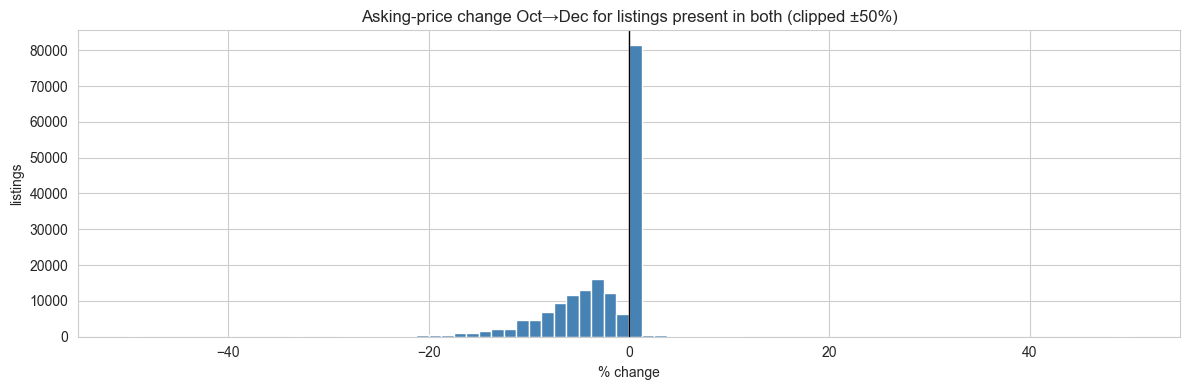

In [5]:
def parse_price(df, col, out):
    return df.with_columns(
        pl.col(col).str.replace_all(r'[^0-9.]', '').cast(pl.Float64, strict=False).alias(out)
    )

oct_p = parse_price(dedup['oct_2025'].select(['url', 'price']), 'price', 'price_oct').select(['url', 'price_oct'])
dec_p = parse_price(dedup['dec_2025'].select(['url', 'price']), 'price', 'price_dec').select(['url', 'price_dec'])

both = (oct_p.join(dec_p, on='url', how='inner')
             .filter((pl.col('price_oct') > 0) & (pl.col('price_dec') > 0)))
both = both.with_columns([
    (pl.col('price_dec') - pl.col('price_oct')).alias('delta'),
    ((pl.col('price_dec') - pl.col('price_oct')) / pl.col('price_oct') * 100).alias('pct'),
])

n = both.height
pct = both['pct']
pct_changed   = (pct.abs() > 1e-9).mean() * 100
pct_decreased = (pct < -1e-9).mean() * 100
pct_increased = (pct > 1e-9).mean() * 100
print(f"Listings in both extractions (valid price): {n:,}")
print(f"  unchanged price : {100 - pct_changed:5.1f}%")
print(f"  price decreased : {pct_decreased:5.1f}%")
print(f"  price increased : {pct_increased:5.1f}%")
print(f"  median signed change : {pct.median():+.2f}%")
print(f"  median |change|      : {pct.abs().median():.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(np.clip(pct.to_numpy(), -50, 50), bins=80, color='steelblue', edgecolor='white')
ax.axvline(0, color='k', lw=1)
ax.set_title('Asking-price change Oct→Dec for listings present in both (clipped ±50%)')
ax.set_xlabel('% change'); ax.set_ylabel('listings')
plt.tight_layout(); plt.show()

## 6. Near-duplicate audit (same car, different url)

The concern is **train/test leakage under a random split**: if two rows describe an identical car
`(brand, model, year, km, price)` but carry different urls, a random split can put one in train and one
in test. This is *not* about removing legitimately common cars — many near-identical Clios are real signal
and must be kept. Per the roadmap: if the exact-match rate is <1–2%, document and skip.

In [6]:
def parse_numeric(df):
    return df.with_columns([
        pl.col('price').str.replace_all(r'[^0-9.]', '').cast(pl.Float64, strict=False).alias('price_num'),
        pl.col('kilometrage').str.replace_all(r'[^0-9.]', '').cast(pl.Float64, strict=False).alias('km_num'),
        pl.col('annee_modele').cast(pl.Float64, strict=False).cast(pl.Int32, strict=False).alias('year_num'),
        pl.col('marque').map_elements(CarDataProcessor._normalize_text, return_dtype=pl.Utf8).alias('brand_n'),
        pl.col('modele').map_elements(CarDataProcessor._normalize_text, return_dtype=pl.Utf8).alias('model_n'),
    ])

m = parse_numeric(merged).filter(
    pl.col('price_num').is_not_null() & (pl.col('price_num') > 0)
    & pl.col('km_num').is_not_null()
    & pl.col('year_num').is_not_null()
    & pl.col('brand_n').is_not_null() & pl.col('model_n').is_not_null()
)

key = ['brand_n', 'model_n', 'year_num', 'km_num', 'price_num']
g = m.group_by(key).agg(n=pl.len(), n_url=pl.col('url').n_unique())
multi = g.filter(pl.col('n_url') > 1)

rows_in_multi  = int(multi['n'].sum()) if multi.height else 0
groups_multi   = multi.height
excess_dupes   = rows_in_multi - groups_multi          # redundant rows if collapsed to 1 per key
near_dup_rate  = excess_dupes / m.height * 100

print(f"Rows audited                         : {m.height:,}")
print(f"Exact-match keys with >1 url         : {groups_multi:,}")
print(f"Rows in those keys                   : {rows_in_multi:,}")
print(f"Redundant near-duplicate rows        : {excess_dupes:,}")
print(f"Near-duplicate rate                  : {near_dup_rate:.3f}%")

# DECISION (taken): rate is 5.36% >> the 1-2% skip threshold. Because the match is on
# exact km AND exact price (not just 'similar Clios'), these are near-certainly the
# same physical car relisted. We apply strict exact-match dedup on the CLEANED dataset
# in Section 8 so the NB14 random-split CV is leakage-free.
print("\nDECISION: rate >= 2% -> strict exact-match dedup APPLIED in Section 8 (on cleaned keys).")


Rows audited                         : 1,262,667
Exact-match keys with >1 url         : 41,884
Rows in those keys                   : 109,511
Redundant near-duplicate rows        : 67,627
Near-duplicate rate                  : 5.356%

DECISION: rate >= 2% -> strict exact-match dedup APPLIED in Section 8 (on cleaned keys).


## 7. Market drift — Oct vs Dec per segment (brand × age bucket)

We compare the **within-extraction deduped** snapshots (each a market snapshot, overlap included) to
quantify price drift per segment. This informs model-refresh cadence for the future API. We restrict to
the same sane price window used in cleaning (€500–€250k) and report median price per (brand, age bucket).

Median segment drift by age bucket (Oct -> Dec):
shape: (6, 3)
┌────────────┬──────────────────┬────────────┐
│ age_bucket ┆ median_drift_pct ┆ n_segments │
│ ---        ┆ ---              ┆ ---        │
│ enum       ┆ f64              ┆ u32        │
╞════════════╪══════════════════╪════════════╡
│ 0-2        ┆ -2.154861        ┆ 49         │
│ 3-5        ┆ -2.075802        ┆ 46         │
│ 6-10       ┆ -0.873853        ┆ 52         │
│ 11-15      ┆ -2.985075        ┆ 47         │
│ 16-20      ┆ 0.0              ┆ 47         │
│ 21+        ┆ 0.0              ┆ 63         │
└────────────┴──────────────────┴────────────┘

Median drift across all qualifying segments: -1.38%
Qualifying segments (n>=30 both): 304

Top 8 segments DOWN:
shape: (8, 5)
┌──────────────┬────────────┬────────────┬────────────┬────────────┐
│ brand_n      ┆ age_bucket ┆ median_oct ┆ median_dec ┆ drift_pct  │
│ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str          ┆ str        ┆ f64      

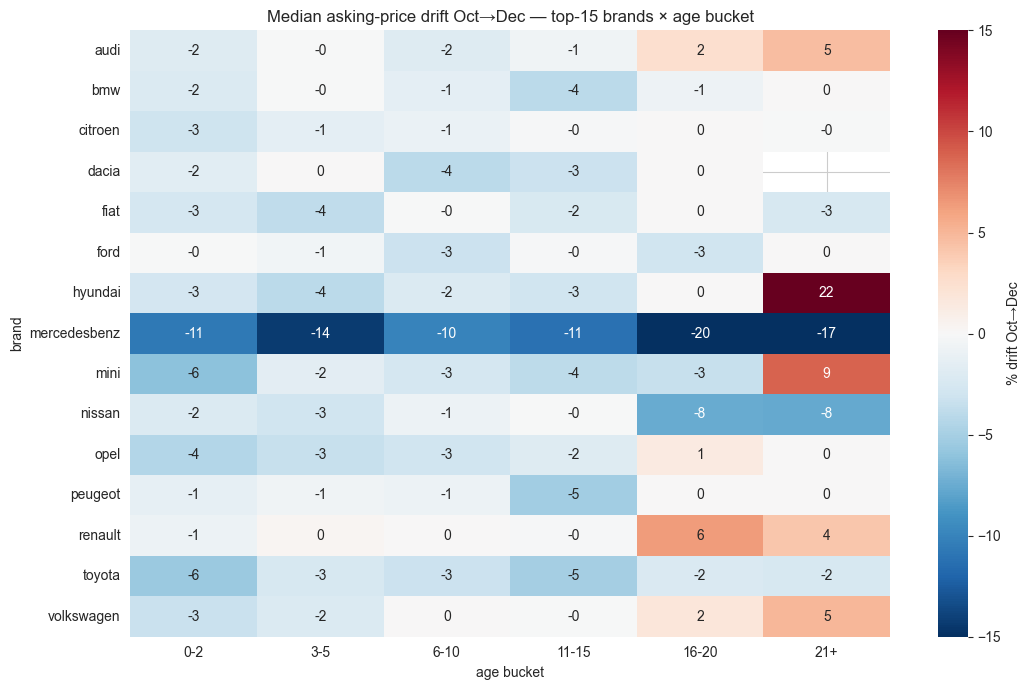

Saved drift table -> /Users/brunobrumbrum/car_price_prediction/output/nb13_drift_table_v1.csv


In [7]:
AGE_BUCKETS = [(0, 2, '0-2'), (3, 5, '3-5'), (6, 10, '6-10'),
               (11, 15, '11-15'), (16, 20, '16-20'), (21, 200, '21+')]

def bucketize(df):
    d = parse_numeric(df).filter(
        (pl.col('price_num') >= 500) & (pl.col('price_num') <= 250000)
        & pl.col('year_num').is_not_null()
        & pl.col('brand_n').is_not_null()
    ).with_columns((CURRENT_YEAR - pl.col('year_num')).alias('age'))
    expr = pl.when(pl.lit(False)).then(pl.lit(None))
    for lo, hi, lbl in AGE_BUCKETS:
        expr = expr.when((pl.col('age') >= lo) & (pl.col('age') <= hi)).then(pl.lit(lbl))
    return d.with_columns(expr.otherwise(pl.lit(None)).alias('age_bucket')).filter(
        pl.col('age_bucket').is_not_null()
    )

oct_b = bucketize(dedup['oct_2025'])
dec_b = bucketize(dedup['dec_2025'])

def seg_median(df, tag):
    return (df.group_by(['brand_n', 'age_bucket'])
              .agg(pl.col('price_num').median().alias(f'median_{tag}'),
                   pl.len().alias(f'n_{tag}')))

drift = (seg_median(oct_b, 'oct').join(seg_median(dec_b, 'dec'),
                                       on=['brand_n', 'age_bucket'], how='inner'))
drift = drift.filter((pl.col('n_oct') >= 30) & (pl.col('n_dec') >= 30)).with_columns(
    ((pl.col('median_dec') - pl.col('median_oct')) / pl.col('median_oct') * 100).alias('drift_pct')
).sort('drift_pct')

bucket_order = [b[2] for b in AGE_BUCKETS]

# Overall drift by age bucket (weighted by segment counts via raw medians)
overall = (drift.group_by('age_bucket')
                .agg(pl.col('drift_pct').median().alias('median_drift_pct'),
                     pl.len().alias('n_segments'))
                .with_columns(pl.col('age_bucket').cast(pl.Enum(bucket_order)))
                .sort('age_bucket'))
print("Median segment drift by age bucket (Oct -> Dec):")
print(overall)
print(f"\nMedian drift across all qualifying segments: {drift['drift_pct'].median():+.2f}%")
print(f"Qualifying segments (n>=30 both): {drift.height:,}")

print("\nTop 8 segments DOWN:")
print(drift.head(8).select(['brand_n', 'age_bucket', 'median_oct', 'median_dec', 'drift_pct']))
print("\nTop 8 segments UP:")
print(drift.tail(8).select(['brand_n', 'age_bucket', 'median_oct', 'median_dec', 'drift_pct']))

# Heatmap for the highest-volume brands
top_brands = (oct_b.group_by('brand_n').len().sort('len', descending=True)
                   .head(15)['brand_n'].to_list())
hm = (drift.filter(pl.col('brand_n').is_in(top_brands))
            .select(['brand_n', 'age_bucket', 'drift_pct'])
            .to_pandas()
            .pivot(index='brand_n', columns='age_bucket', values='drift_pct')
            .reindex(columns=bucket_order))
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(hm, annot=True, fmt='.0f', center=0, cmap='RdBu_r', vmin=-15, vmax=15,
            cbar_kws={'label': '% drift Oct→Dec'}, ax=ax)
ax.set_title('Median asking-price drift Oct→Dec — top-15 brands × age bucket')
ax.set_xlabel('age bucket'); ax.set_ylabel('brand')
plt.tight_layout(); plt.show()

drift_csv = output_dir / f'nb13_drift_table_{VERSION_TAG}.csv'
drift.write_csv(drift_csv)
print('Saved drift table ->', drift_csv)

## 8. Clean the merged dataset, dedup & save (version-tagged)

We run the validated V2 cleaning (`CarDataProcessor`, brand+year IQR, price €500–€250k). `CarDataProcessor`
is stateless, so cleaning the merged set is correct. We then apply **strict exact-match dedup** on
`(brand, model, year, km, price)` — the decision from Section 6 (near-dup rate 5.36% ≫ the 2% skip
threshold). We save two artifacts:

- **`merged_oct_dec_clean_v1.parquet`** — cleaned + deduped, training-ready dataset (NB14 input).
- **`merged_oct_dec_raw_v1.parquet`** — deduped-by-url raw with `url` + `extraction` provenance, for the
  future out-of-time split and drift work (not exact-match deduped, so it stays a faithful market record).

In [8]:
proc = CarDataProcessor(**CLEAN_PARAMS)
merged_clean = proc.clean_data(merged)

# ── Strict exact-match dedup (decision: near-dup rate 5.36% > 2% threshold) ──
# Collapse rows identical on (brand, model, year, km, price) to a single row. Exact
# agreement on both km and price makes these near-certainly the same physical car
# relisted under a new url; keeping them would leak across a random CV split (NB14).
DEDUP_KEYS = ['brand', 'model', 'year', 'km', 'price']
n_pre_dedup = merged_clean.height
merged_clean = merged_clean.unique(subset=DEDUP_KEYS, keep='first', maintain_order=True)
n_dedup_dropped = n_pre_dedup - merged_clean.height

merged_clean = merged_clean.with_columns(pl.col('price').log().alias('log_price'))

clean_path = processed / f'merged_oct_dec_clean_{VERSION_TAG}.parquet'
merged_clean.write_parquet(clean_path)

prov_cols = ['url', 'extraction', 'index_date', 'marque', 'modele', 'annee_modele',
             'kilometrage', 'price', 'energie', 'puissance_din']
raw_path = processed / f'merged_oct_dec_raw_{VERSION_TAG}.parquet'
merged.select(prov_cols).write_parquet(raw_path)

print(f"Cleaned rows (pre-dedup) : {n_pre_dedup:,}")
print(f"Exact-match dedup dropped: {n_dedup_dropped:,}  ({n_dedup_dropped / n_pre_dedup * 100:.2f}%)")
print(f"Merged clean rows (final): {merged_clean.height:,}")
print(f"Year range        : {merged_clean['year'].min()} - {merged_clean['year'].max()}")
print(f"Brands / models   : {merged_clean['brand'].n_unique()} / {merged_clean['model'].n_unique()}")
print(f"Saved clean -> {clean_path}")
print(f"Saved raw   -> {raw_path}")

🧹 Starting data cleaning pipeline...

1️⃣ Converting data types and normalizing text...


   Original: 1,262,668 rows
   After conversion: 1,262,667 rows
   Removed (invalid price): 1
   Unique brands: 149, Unique models: 1717

1️⃣b Applying hard price bounds...
   Price floor  : 500 € — dropped 4,558 rows
   Price ceiling: 250000 € — dropped 1,007 rows
   Remaining    : 1,257,102 rows

2️⃣ Removing antique cars (pre-1990)...
   Removed 23,205 antique cars

3️⃣ Removing 'autre' entries...
   Removed 6,355 'autre' entries

4️⃣ Cleaning horsepower...


   HP cleaning: dropped 9058 cars <50HP, 160 cars >1000HP, 62541 outliers (IQR per brand), 0 missing HP
   Remaining dataset - Mean HP: 137.9, Median HP: 122.0

5️⃣ Dropping rare brands (<400 cars)...
   Dropped 4,107 cars from 67 rare brands (< 400 observations)
   Remaining: 47 brands

6️⃣ Removing price/km outliers (brand+year IQR 1.5×; iqr_large_group≥50; iqr_min_pool=10)...


   brand='aston martin'        year=2000  pool_size=9  → DROPPED (below iqr_min_group_size=10)


   brand='lancia'              year=2001  pool_size=6  → DROPPED (below iqr_min_group_size=10)
   brand='chrysler'            year=2014  pool_size=1  → DROPPED (below iqr_min_group_size=10)


...

   brand='lexus'               year=1998  pool_size=7  → DROPPED (below iqr_min_group_size=10)
   brand='lancia'              year=1993  pool_size=9  → DROPPED (below iqr_min_group_size=10)


   brand='seat'                year=1994  pool_size=2  → DROPPED (below iqr_min_group_size=10)
   brand='lancia'              year=2000  pool_size=5  → DROPPED (below iqr_min_group_size=10)


   brand='dodge'               year=2001  pool_size=7  → DROPPED (below iqr_min_group_size=10)


   Before         : 1,105,266 rows
   Removed by IQR : 44,018
   Removed (tiny groups < 10): 125
   After          : 1,061,123 rows  (4.0% removed total)

✅ Data cleaning completed!
Final dataset: 1,061,123 rows × 7 columns


Cleaned rows (pre-dedup) : 1,061,123
Exact-match dedup dropped: 57,994  (5.47%)
Merged clean rows (final): 1,003,129
Year range        : 1990 - 2025
Brands / models   : 47 / 1054
Saved clean -> /Users/brunobrumbrum/car_price_prediction/data/processed/merged_oct_dec_clean_v1.parquet
Saved raw   -> /Users/brunobrumbrum/car_price_prediction/data/processed/merged_oct_dec_raw_v1.parquet


## 9. Log merge summary to MLflow

In [9]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment('nb13_merge_oct_dec')

merge_metrics = dict(
    rows_oct_raw=int(raw['oct_2025'].height),
    rows_dec_raw=int(raw['dec_2025'].height),
    oct_within_dups=int(raw['oct_2025'].height - dedup['oct_2025'].height),
    dec_within_dups=int(raw['dec_2025'].height - dedup['dec_2025'].height),
    url_overlap=int(n_overlap),
    merged_union_rows=int(n_union),
    near_dup_rate_pct=float(near_dup_rate),
    exact_dedup_dropped=int(n_dedup_dropped),
    clean_rows_pre_dedup=int(n_pre_dedup),
    merged_clean_rows=int(merged_clean.height),
    median_segment_drift_pct=float(drift['drift_pct'].median()),
)

with mlflow.start_run(run_name=f'merge_dedup_drift_{VERSION_TAG}'):
    mlflow.set_tags({'notebook': 'NB13', 'stage': 'data_merge', 'version': VERSION_TAG})
    mlflow.log_params({**CLEAN_PARAMS, 'extractions': 'oct_2025+dec_2025',
                       'recency_keep': 'dec_2025', 'near_dup_decision': 'strict_exact_match_dedup',
                       'dedup_keys': '+'.join(DEDUP_KEYS)})
    mlflow.log_metrics(merge_metrics)
    mlflow.log_artifact(str(drift_csv))
    summary_path = output_dir / f'nb13_summary_{VERSION_TAG}.json'
    summary_path.write_text(json.dumps(merge_metrics, indent=2))
    mlflow.log_artifact(str(summary_path))

print('Logged NB13 run to MLflow:')
for k, v in merge_metrics.items():
    print(f'  {k:26s}: {v}')

Logged NB13 run to MLflow:
  rows_oct_raw              : 732427
  rows_dec_raw              : 728908
  oct_within_dups           : 139
  dec_within_dups           : 18384
  url_overlap               : 180144
  merged_union_rows         : 1262668
  near_dup_rate_pct         : 5.355885597707076
  exact_dedup_dropped       : 57994
  clean_rows_pre_dedup      : 1061123
  merged_clean_rows         : 1003129
  median_segment_drift_pct  : -1.3800254000130467


## 10. Conclusions & handoff to NB14

- **Merge done:** October + December deduped by `url` (within- and cross-extraction), December kept on
  conflict. Counts and near-duplicate rate logged to MLflow and saved to `output/`.
- **December is no longer a held-out test set** — it is now part of the merged training data. Until a
  fresh extraction exists, development uses a **random split** (NB14 CV harness); the **only honest
  customs measure** remains an **out-of-time test set from a fresh LeBonCoin extraction** (it is June 2026
  — schedule one).
- **Near-duplicate decision:** the audit found **5.36%** exact `(brand, model, year, km, price)` matches
  under different urls — well above the 1–2% skip threshold. Because the match pins exact km *and* price,
  these are near-certainly the same physical car relisted, so we applied **strict exact-match dedup** on
  the cleaned dataset (Section 8) to keep the NB14 random-split CV leakage-free. Legitimately distinct
  common cars (differing on any of km/price/year) are kept.
- **Drift** quantified per segment — see heatmap and `nb13_drift_table_v1.csv`; feeds model-refresh cadence.
- **Artifacts:** `data/processed/merged_oct_dec_clean_v1.parquet` (cleaned + deduped, NB14 input) and
  `merged_oct_dec_raw_v1.parquet` (url-deduped provenance for the future out-of-time split).

**Next (NB14):** 5-fold CV harness with the feature engineer refit **inside each fold**, cross-validating
q50 and q85 pinball loss *and* Q15–Q85 coverage, reproducing the V2 baseline within fold noise.